# 01 — Reading the absorber catalog and the raw spectra

In notebook 00 you saw that every (sim, snap) has a small `catalog.npz` of
per-absorber records and a much larger raw-spectra HDF5 file holding the
optical depth on every sightline.  Here you will:

1. Load `catalog.npz` and inspect the per-absorber records.
2. Load `meta.json` and confirm the catalog is internally consistent
   (counts in `meta.json` match what's in `catalog.npz`).
3. Open the raw spectra HDF5 file *without* loading it into memory.
4. Pick one DLA from the catalog and visualise its `tau(v)` and `F(v)`.

The end-state mental model: a DLA is just a contiguous run of high-`tau`
pixels on one specific sightline, identified and characterised by the
catalog builder in `hcd_analysis.catalog`.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import h5py

DATA_ROOT    = Path('/nfs/turbo/umor-yueyingn/mfho/emu_full')
HCD_OUT_ROOT = Path('/scratch/cavestru_root/cavestru0/mfho/hcd_outputs')

# A sim known to have snap_022 fully processed (used in NB00):
SIM = 'ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333'
SNAP = 22

SIM_DIR  = HCD_OUT_ROOT / SIM
SNAP_DIR = SIM_DIR / f'snap_{SNAP:03d}'
RAW_FILE = DATA_ROOT / SIM / 'output' / f'SPECTRA_{SNAP:03d}' / 'lya_forest_spectra_grid_480.hdf5'

print('catalog dir :', SNAP_DIR)
print('raw file    :', RAW_FILE, '->', RAW_FILE.exists())


catalog dir : /scratch/cavestru_root/cavestru0/mfho/hcd_outputs/ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333/snap_022
raw file    : /nfs/turbo/umor-yueyingn/mfho/emu_full/ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333/output/SPECTRA_022/lya_forest_spectra_grid_480.hdf5 -> True


## 1. `meta.json` — the per-(sim, snap) metadata

This is just a plain JSON file.  Read it first because it tells you what
snapshot you are looking at, what cosmology was used, and how many
absorbers of each class were found.  Anything in `meta.json` is the
authoritative answer for that (sim, snap).


In [2]:
with open(SNAP_DIR / 'meta.json') as f:
    meta = json.load(f)

# Pretty-print the structured fields
import textwrap
print('Top-level meta:')
for k, v in meta.items():
    if isinstance(v, dict):
        print(f'  {k}:')
        for kk, vv in v.items():
            print(f'      {kk:20s} = {vv}')
    else:
        print(f'  {k:14s} = {v}')


Top-level meta:
  sim_name       = ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333
  snap           = 22
  z              = 2.0
  dv_kms         = 10.00505191229706
  nbins          = 1228
  n_skewers      = 691200
  box_kpc_h      = 120000.0
  hubble         = 0.6683333333333333
  n_absorbers:
      LLS                  = 55070
      subDLA               = 17641
      DLA                  = 9051
      forest               = 0
  timing_s:
      header               = 0.013
      catalog              = 9.65
      p1d                  = 109.286
      excl_sweep           = 433.786
      cddf                 = 0.03
  sim_ics:
      npart                = 192.0
      ics_box              = 15.0
      omega0               = 0.3244009676556738
      ics_omegab           = 0.050148941859814306
      ics_hubble           = 0.6683333333333333
      ics_ns               = 0.8097500000000001
      scalar_amp           = 2.6963487591286194e-09
      her

A few things worth noting in the above:

* `n_skewers = 691200` — 691 200 sightlines per snapshot.  This is `2 ×
  3 × 480²` (the factor of 3 is the LOS axis, factor of 2 because each
  axis position is sampled twice for the regular grid).  Streaming 3 GB
  is fast; loading it whole is a mistake.
* `dv_kms` is the pixel velocity width.  At z = 2.2 this is ~10 km/s.
  It varies smoothly with z and a bit across sims.
* `n_absorbers` is the **total absorber count** (not per sightline).  The
  classes are LLS / subDLA / DLA defined by:

  | Class | log₁₀ NHI |
  |---|---|
  | LLS    | [17.2, 19.0) |
  | subDLA | [19.0, 20.3) |
  | DLA    | ≥ 20.3       |

  These boundaries are fixed across the project — they are the
  conventional Wolfe & Prochaska classifications.


## 2. `catalog.npz` — one row per absorber

`catalog.npz` stores parallel arrays, one entry per absorber found.
Total size = `n_LLS + n_subDLA + n_DLA` (e.g. 81 762 absorbers in the
example sim).


In [3]:
cat = np.load(SNAP_DIR / 'catalog.npz', allow_pickle=True)

print('Fields and their shapes:')
for k in cat.files:
    a = cat[k]
    shape_str = str(getattr(a, 'shape', '()'))
    print(f'  {k:14s} shape={shape_str:>12} dtype={a.dtype}')
print()
print('First 5 rows of the per-absorber arrays:')
n_show = 5
print(f'{"idx":>5} {"skewer":>8} {"pix_lo":>6} {"pix_hi":>6} {"log NHI":>8} {"b kms":>6}  fit  fast')
for i in range(n_show):
    print(f'{i:>5} {int(cat["skewer_idx"][i]):>8} {int(cat["pix_start"][i]):>6} {int(cat["pix_end"][i]):>6} '
          f'{np.log10(cat["NHI"][i]):>8.3f} {cat["b_kms"][i]:>6.1f}'
          f'  {bool(cat["fit_success"][i])!s:>5} {bool(cat["fast_mode"][i])!s:>5}')


Fields and their shapes:
  sim_name       shape=          () dtype=<U92
  snap           shape=          () dtype=int64
  z              shape=          () dtype=float64
  dv_kms         shape=          () dtype=float64
  skewer_idx     shape=    (81762,) dtype=int32
  pix_start      shape=    (81762,) dtype=int32
  pix_end        shape=    (81762,) dtype=int32
  NHI            shape=    (81762,) dtype=float64
  b_kms          shape=    (81762,) dtype=float64
  fit_success    shape=    (81762,) dtype=bool
  fast_mode      shape=    (81762,) dtype=bool

First 5 rows of the per-absorber arrays:
  idx   skewer pix_lo pix_hi  log NHI  b kms  fit  fast
    0        6     83    108   19.035    nan   True  True
    1       14    648    674   20.118    nan   True  True
    2       25     75     83   17.368    nan   True  True
    3       25    466    481   19.771    nan   True  True
    4       25    986   1006   18.868    nan   True  True


Field-by-field:

* **`skewer_idx`** — index into the raw-spectra HDF5 row dimension; pulls
  out which sightline this absorber lives on.
* **`pix_start`, `pix_end`** — first and last pixel of the absorber along
  that sightline (inclusive).  For systems that wrap across the periodic
  box boundary, `pix_end >= nbins`; the wrapped portion is `[pix_start:]`
  and `[:pix_end - nbins + 1]`.
* **`NHI`** — column density in cm⁻² (use `log10(NHI)` for plots).
* **`b_kms`** — Doppler parameter from the Voigt fit (NaN in `fast_mode`).
* **`fit_success`** — True if the Voigt fit converged.  False rows are
  rare and you can usually drop them for plots.
* **`fast_mode`** — True if `NHI` came from the fast tau-integral
  estimator instead of a Voigt fit.  This is the production setting for
  the LF run; the HR run uses Voigt fits.

A consistency check: the per-class counts in `meta.json` should match
what we get from binning `NHI` ourselves.


In [4]:
log_nhi = np.log10(cat['NHI'])

n_lls    = int(((log_nhi >= 17.2) & (log_nhi < 19.0)).sum())
n_subdla = int(((log_nhi >= 19.0) & (log_nhi < 20.3)).sum())
n_dla    = int( (log_nhi >= 20.3).sum())

print(f'computed: LLS={n_lls:,}  subDLA={n_subdla:,}  DLA={n_dla:,}')
print(f'meta:     LLS={meta["n_absorbers"]["LLS"]:,}  '
      f'subDLA={meta["n_absorbers"]["subDLA"]:,}  '
      f'DLA={meta["n_absorbers"]["DLA"]:,}')


computed: LLS=55,070  subDLA=17,641  DLA=9,051
meta:     LLS=55,070  subDLA=17,641  DLA=9,051


## 3. log NHI distribution

A canonical first plot: the per-absorber log NHI distribution, with the
class boundaries marked.  The catalog goes down to log NHI ≈ 17.2 by
construction (any absorber below that is treated as part of the smooth
forest, not an HCD).


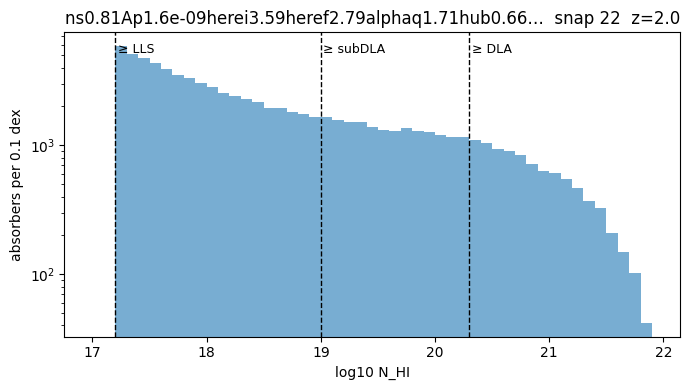

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_nhi, bins=np.arange(17.0, 22.0, 0.1), histtype='stepfilled', alpha=0.6)
for boundary, label in [(17.2, 'LLS'), (19.0, 'subDLA'), (20.3, 'DLA')]:
    ax.axvline(boundary, color='k', linestyle='--', linewidth=1)
    ax.text(boundary + 0.02, ax.get_ylim()[1] * 0.85, f'≥ {label}', fontsize=9)
ax.set(xlabel='log10 N_HI', ylabel='absorbers per 0.1 dex', title=f'{SIM[:50]}…  snap {SNAP}  z={meta["z"]}')
ax.set_yscale('log')
fig.tight_layout()
plt.show()


## 4. The richer interface: `AbsorberCatalog`

`hcd_analysis.catalog.AbsorberCatalog` is a dataclass that wraps the same
arrays with helpful accessors (`by_class`, `summary`, `to_dataframe`).  Use
it when you want to operate on absorbers as objects rather than arrays.


In [6]:
from hcd_analysis.catalog import AbsorberCatalog

ac = AbsorberCatalog.load_npz(SNAP_DIR / 'catalog.npz')
print('summary:', ac.summary())   # should match meta.json
dlas = ac.by_class('DLA')
print(f'first DLA in catalog: skewer={dlas[0].skewer_idx} '
      f'pix=({dlas[0].pix_start}, {dlas[0].pix_end}) log NHI={dlas[0].log_NHI:.3f}')


summary: {'LLS': 55070, 'subDLA': 17641, 'DLA': 9051, 'forest': 0}
first DLA in catalog: skewer=79 pix=(1076, 1122) log NHI=20.327


## 5. Opening the raw spectra HDF5 — without loading it

The raw file is ~3 GB.  The trick is to keep it on disk and stream only
the rows you need.  h5py datasets behave like numpy arrays for slicing
but the data is only fetched for the slice you ask for.

The full schema is in `docs/data_layout.md`.  The two datasets you almost
always touch:

* `tau/H/1/1215`  — shape `(n_skewers, nbins)`, float32, optical depth.
* `spectra/cofm`  — shape `(n_skewers, 3)`, float64, sightline starting
  position in **kpc/h** (comoving).

Everything else (`colden`, `tau_obs`, `temperature`, `velocity`) exists
but is **empty** — they were not stored.  Don't try to read from them.


In [7]:
with h5py.File(RAW_FILE, 'r') as f:
    print('Header attrs:')
    for k, v in f['Header'].attrs.items():
        print(f'  {k:10s} = {v}')
    print('Datasets:')
    for name in ('tau/H/1/1215', 'spectra/cofm', 'spectra/axis'):
        d = f[name]
        print(f'  {name:20s} shape={d.shape} dtype={d.dtype}')


Header attrs:
  Hz         = 205.281987627859
  box        = 120000.0
  discarded  = 0
  hubble     = 0.6683333333333333
  nbins      = 1228
  npart      = [3563234041 3623878656          0          0   60616097      28518]
  omegab     = 0.050148941859814306
  omegal     = 0.6755990323443262
  omegam     = 0.3244009676556738
  redshift   = 2.0
Datasets:
  tau/H/1/1215         shape=(691200, 1228) dtype=float32
  spectra/cofm         shape=(691200, 3) dtype=float64
  spectra/axis         shape=(691200,) dtype=int32


A quick sanity check on the velocity-pixel width: `pixel_dv_kms()` from
`hcd_analysis.io` recomputes `dv_kms` from cosmology and should match
the value cached in `meta.json`.


In [8]:
from hcd_analysis.io import read_header, pixel_dv_kms
hdr = read_header(RAW_FILE)
dv_recomputed = pixel_dv_kms(hdr)
print(f'meta.dv_kms       = {meta["dv_kms"]:.6f}')
print(f'recomputed dv_kms = {dv_recomputed:.6f}')


meta.dv_kms       = 10.005052
recomputed dv_kms = 10.005052


## 6. Visualising one DLA

The per-absorber records hand you a `(skewer_idx, pix_start, pix_end)`
triple.  To see what that absorber actually looks like in flux space,
load just that one row of `tau`, convert to `F = exp(-tau)`, and plot.


DLA chosen: skewer=279805  log NHI=22.960  pix=(37, 405)


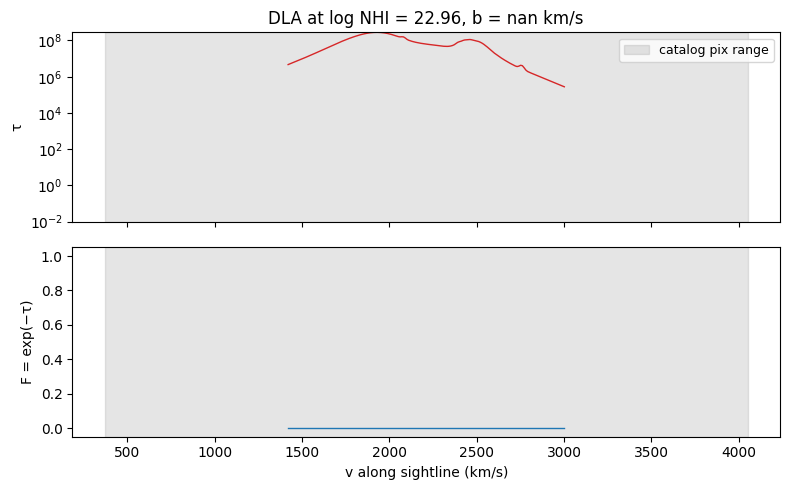

In [9]:
# Pick the highest-NHI DLA in the catalog so the damping wings are
# obvious.  ac.by_class('DLA') returns a list of Absorber objects.
dla = max(ac.by_class('DLA'), key=lambda a: a.NHI)
print(f'DLA chosen: skewer={dla.skewer_idx}  log NHI={dla.log_NHI:.3f}  '
      f'pix=({dla.pix_start}, {dla.pix_end})')

# Stream just this one row of tau.
with h5py.File(RAW_FILE, 'r') as f:
    tau_row = f['tau/H/1/1215'][dla.skewer_idx, :].astype(np.float64)
F_row = np.exp(-tau_row)

dv = float(meta['dv_kms'])
v  = np.arange(len(tau_row)) * dv  # km/s along the sightline

# Show a window around the absorber.
half_window = 800.0  # km/s on each side
v_centre = 0.5 * (dla.pix_start + dla.pix_end) * dv
sel = (v > v_centre - half_window) & (v < v_centre + half_window)

fig, (ax_t, ax_f) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax_t.plot(v[sel], tau_row[sel], color='C3', lw=1.0)
ax_t.set(ylabel='τ', yscale='log', ylim=(1e-2, max(2.0, tau_row[sel].max())))
ax_t.axvspan(dla.pix_start * dv, dla.pix_end * dv, color='grey', alpha=0.2, label='catalog pix range')
ax_t.legend(loc='upper right', fontsize=9)
ax_t.set_title(f'DLA at log NHI = {dla.log_NHI:.2f}, b = {dla.b_kms:.1f} km/s')

ax_f.plot(v[sel], F_row[sel], color='C0', lw=1.0)
ax_f.set(xlabel='v along sightline (km/s)', ylabel='F = exp(−τ)', ylim=(-0.05, 1.05))
ax_f.axvspan(dla.pix_start * dv, dla.pix_end * dv, color='grey', alpha=0.2)

fig.tight_layout()
plt.show()


**What you're looking at.**  The catalog's `(pix_start, pix_end)` window
(grey band) is the *core* of the absorber — the contiguous run where
τ exceeds the catalog detection threshold (`tau_threshold = 100`).
For a DLA, the *damping wings* extend much further out — you can see
the flux dipping well outside the grey band.  The Voigt fitter widens
its fit window by a few hundred km/s on each side of the core
specifically to capture those wings (where most of the NHI information
lives).  This is why `pix_start..pix_end` is short but `NHI` can still
be 10²⁰·⁵ — the catalog reports the column-density inferred from the
*full* Voigt profile, not the count of pixels above τ_threshold.

## Where to next

* **Notebook 02** — turn the per-absorber catalog into the column-density
  distribution function (CDDF) and dN/dX, and compare to literature.
* **Notebook 03** — turn the raw spectra + catalog into the per-class
  P1D templates that feed the emulator.
